The goal of this analysis is to apply corrections to measured data, with the goal of obtaining the true physical curves showing:

$\textbf{Luminescence vs Photon flux}$

These corrections are needed because $\textbf{the measured values are Luminescence vs Pump power}$, and since we are using a $\textbf{gaussian laser beam}$, the $\textbf{ANPs in the sample could be excited by a specific portion of the laser spot}$. 

Let's imagine a circular laser spot on the sample, because of the pump laser being shot at $\textbf{normal incidence}$. In general, when using a carpet of ANPs, $\textbf{some}$ particles could be at the $\textbf{center}$ of the gaussian beam, $\textbf{receiving more power and therefore emitting more}$, while $\textbf{others could be near the side of the circular spot}$, receiving less and emitting less. This is the reason considering the photon flux and the shape of the laser spot is important. This is relevant also because if the excitation happens by total internal reflection ($\textbf{TIR}$) on the sample, because of the microscope objective the laser spot will have a distorted, more oval shape.

In conclusion, if you want to display the luminescence in function of a more $\textbf{"excitation independent"}$ parameter, the $\textbf{photon flux (number of photons/seconds/area)}$ considering the shape of the laser spot on the sample is crucial. 

This is important both in the case of single ANPs or with a carpet of them.

Step 1: $\textbf{calculating the power that actually reaches the sample}$ (whatever it could be)

In our experimental setup what is being measured is a fraction of the power reflected by a simple glass sheet, before the light interacts with the sample. The power is modulated by a $\lambda / 2$ waveplate placed before a polarized beam splitter.

We measure, after the beam splitter, the power reflected and transmitted by the glass sheet, to obtain a linear relationship where the coefficient represents the conversion factor between reflected and transmitted power.

$\textbf{ASSUMPTION:}$ the absorption of the glass sheet is negligible.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import warnings

warnings.simplefilter('ignore', np.RankWarning)

In [29]:
# Measured data

theta = np.array([30.0, 35.0, 40.0, 45.0]) # In degrees

power_reflected = np.array([0.26, 0.73, 4.08, 10.00]) # In mW, truncated
uncertainty_reflected = np.array([0.01, 0.01, 0.01, 0.01]) # If needed, here it is not useful to consider

power_transmitted = np.array([2.93, 11.21, 69.50, 172.20]) # In mW
uncertainty_transmitted = np.array([0.01, 0.01, 0.01, 0.01])

data = pd.DataFrame({'theta': theta, 'power_reflected': power_reflected, 'uncertainty_reflected': uncertainty_reflected, 'power_transmitted': power_transmitted, 'uncertainty_transmitted': uncertainty_transmitted})

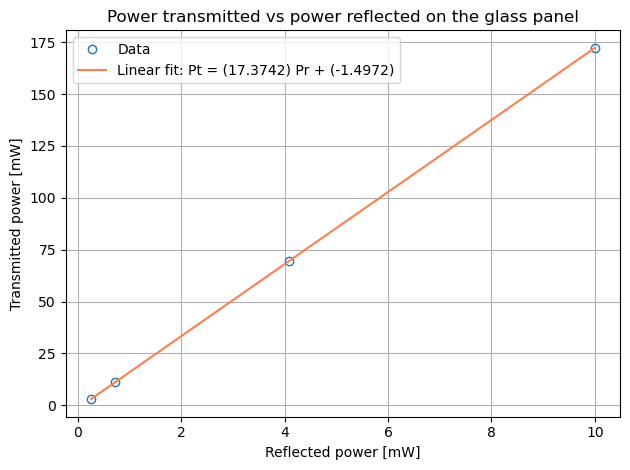


Pr / Pt = 0.06



In [33]:
# Calculating the linear fit
slope, intercept = np.polyfit(data['power_reflected'], data['power_transmitted'], 1)
fit_line = slope * data['power_reflected'] + intercept

plt.plot(data['power_reflected'], data['power_transmitted'], 'o', markerfacecolor='none', label='Data')
plt.plot(data['power_reflected'], fit_line, '-', color='coral', label=f'Linear fit: Pt = ({slope:.4f}) Pr + ({intercept:.4f})')
plt.xlabel('Reflected power [mW]')
plt.ylabel('Transmitted power [mW]')
plt.title('Power transmitted vs power reflected on the glass panel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nPr / Pt = {1/slope:.2f}\n') # 1/slope is the ratio power_reflected/power_transmitted

THE GOAL IS TO COMPARE A SINGLE ANP MEASUREMENT THAT YOU DO, TO A ENSEMBLE MEASUREMENT PREDICTED BY THEORY, BY CORRECTING THE SINGLE ANP MEASURED DATA

Step 2: $\textbf{simulation (or choice, in this case) of a single ANP power curve as a starting reference point for the gaussian corrections}$

The goal is to have the function of an ideal power curve of a single ANP, as well as a reference of its measured values.

In this case, a good, $\textbf{previous measurement of the power curve of a carpet of ANPs}$, excited at $\textbf{normal incidence}$, is taken into consideration $\textbf{PRETENDING}$ it is a measurement of a single ANP to which different corrections to achieve excitation independence are applied.

This power curve will be then fitted to obtain the mathematical function that every power curve follows, such that it can be integrated in a certain way to achieve the correction to luminescence in ensemble configurations.

In [35]:
conversion_factor = 1/slope # Obtain power on the sample by dividing the measured power with this factor

single_anp = pd.read_csv('fake_single_anp.csv')
single_anp.drop(single_anp.columns[0], axis=1, inplace=True)
integration_time = 3 # In seconds

single_anp['Power_W'] = single_anp['Power_W'] / conversion_factor
single_anp['Luminescence_counts'] = single_anp['Integrated_counts'] / integration_time
single_anp.drop(single_anp.columns[1], axis=1, inplace=True)

display(single_anp)

,Power_W,Luminescence_counts
0,0.001687,32.266396
1,0.001801,32.836030
2,0.001945,37.099134
3,0.002112,30.525933
4,0.002307,50.165079
5,0.002537,275.811865
6,0.002809,937.718319
7,0.003124,2000.648865
8,0.003488,3478.348081
9,0.003911,5534.654539


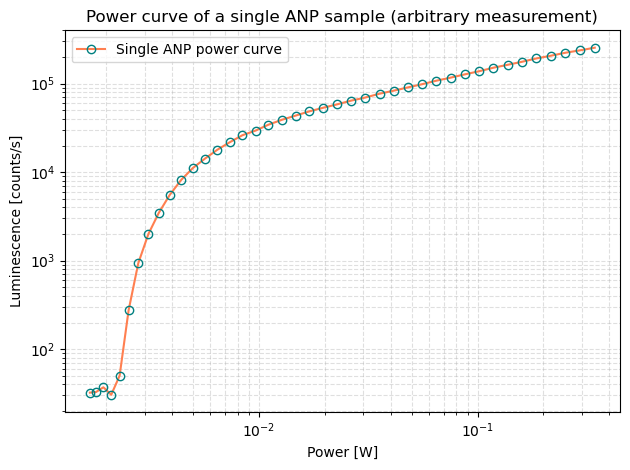

In [37]:
plt.loglog(single_anp['Power_W'], single_anp['Luminescence_counts'], '-o', markerfacecolor='none',
           color='coral', markeredgecolor='teal', label='Single ANP power curve')
plt.xlabel('Power [W]')
plt.ylabel('Luminescence [counts/s]')
plt.title('Power curve of a single ANP sample (arbitrary measurement)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Some parameters and considerations:

The spectrometer hole is 0.05 mm, so 50 um.

$\textbf{ASSUMPTION:}$ beam radius is 532 nm, assumed half of the wavelength. So $\textbf{FWHM is 1.18 $\cdot$ 532 nm}$ (source: https://www.rp-photonics.com/gaussian_beams.html)

In [47]:
wavelength = 1064 * 1e-9 # 1064 nm
FWHM = 1.18 * 532 * 1e-9
#print(f'\nFWHM = {FWHM} m')

nu = const.c / wavelength
#print(f'\nnu = {nu} Hz')

hnu = const.h * nu
#print(f'\nhnu = {hnu} J') # Or W*s

nu = c/lambda

1 W = 1 J/s

ASSUMPTION: power density of the oval beam spot on the sample is constant
ASSUMPTION: laser spot is of the same dimension in a direction and around 3 times in the other

In [ ]:
TIR_FWHM = 3 * FWHM

single_anp['TIR_phi_exc'] = single_anp['Power_W'] / hnu / (np.pi * TIR_FWHM*FWHM * 4)

In [ ]:
single_anp['Phi_exc'] = single_anp['Power_W'] / hnu / (np.pi * FWHM**2 * 4) # NO TIR, single anp or not is irrelevant
single_anp['Phi_peak'] = single_anp['Phi_exc'] * 1.47 # Taken from the paper

In [ ]:
plt.loglog(single_anp['Phi_exc'], single_anp['Luminescence_counts'], '-o', markerfacecolor='none',
           color='coral', markeredgecolor='teal', label='Single ANP power curve')
plt.xlabel('Phi_exc [1/s/m^2]')
plt.ylabel('Luminescence [counts/s]')
plt.title('Power curve of a single ANP sample (arbitrary measurement),\nluminescence vs flux')

In [ ]:
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.loglog(single_anp['Phi_peak'], single_anp['Luminescence_counts'], '-o', markerfacecolor='none',
           color='coral', markeredgecolor='teal', label='Single ANP power curve')
plt.xlabel('Phi_peak [1/s/m^2]')
plt.ylabel('Luminescence [counts/s]')
plt.title('Power curve of a single ANP sample (arbitrary measurement),\nluminescence vs peak flux')

In [ ]:
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(single_anp)

I need the power curve single ANP function

In [ ]:
phi_exc = single_anp['Phi_exc'].values
lum = single_anp['Luminescence_counts'].values

In [ ]:
log_phi = np.log10(phi_exc)
log_lum = np.log10(lum)

In [ ]:
loglog_interpolation = interp1d(log_phi, log_lum, kind='linear', fill_value='extrapolate')

In [ ]:
def powercurve_singleANP(phi):

    log_phi_input = np.log10(phi)

    return 10 ** loglog_interpolation(log_phi_input)

Create points for plotting the piecewise interpolation

In [ ]:
phi_fit = []

In [ ]:
for i in range(len(phi_exc) - 1):

    phi_segment = np.logspace(np.log10(phi_exc[i]), np.log10(phi_exc[i + 1]), 100)
    phi_fit.extend(phi_segment)

In [ ]:
phi_fit = np.array(phi_fit)
lum_fit = powercurve_singleANP(phi_fit)

In [ ]:
plt.loglog(phi_exc, lum, 'o', markerfacecolor='none', label='Data', color='teal')
plt.loglog(phi_fit, lum_fit, '-', color='coral', label='Piecewise linear fit')
plt.xlabel('Phi_exc [1/s/m^2]')
plt.ylabel('Luminescence [counts/s]')
plt.title('Luminescence vs flux (piecewise linear fit in log-log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print(poly)

Test:

plt.loglog(phi_exc, powercurve_singleANP(phi_exc), 'o-', label='NO TIR', color='teal', markerfacecolor='none')
plt.show()

print(phi_exc)
print(powercurve_singleANP(phi_exc))

In [ ]:
single_anp['Phi_exc_NOTIR'] = single_anp['Phi_exc']
single_anp['Phi_exc_TIR'] = single_anp['Power_W'] / hnu / (np.pi * TIR_FWHM*FWHM * 4)

In [ ]:
phi_array = np.logspace(np.log10(single_anp['Phi_exc'].min()) - 1,
                       np.log10(single_anp['Phi_exc'].max()) + 1,
                       5000)

In [ ]:
integrand_values = powercurve_singleANP(phi_array) / phi_array

In [ ]:
cumulative_integral = cumulative_trapezoid(integrand_values, phi_array)
cumulative_integral = np.insert(cumulative_integral, 0, 0)

In [ ]:
integral_interp_func = interp1d(phi_array, cumulative_integral, kind='linear', fill_value='extrapolate')

In [ ]:
single_anp['Ensemble_f_phi_exc_NOTIR'] = integral_interp_func(single_anp['Phi_exc_NOTIR'])
single_anp['Ensemble_f_phi_exc_TIR'] = integral_interp_func(single_anp['Phi_exc_TIR'])

From article code:

f_I = population_3H4_array / P_pump_array
population_3H4_gaussian_array = cumtrapz(f_I, P_pump_array, initial=min(P_pump_array))
population_3H4_gaussian_array = np.array(population_3H4_gaussian_array)

In [ ]:
pd.set_option('display.max_columns', None)
print(single_anp)

In [ ]:
plt.plot(single_anp['Phi_exc_NOTIR'], single_anp['Ensemble_f_phi_exc_NOTIR'],
         '-o', label='Ensemble No TIR correction', color='blue', markerfacecolor='none')
plt.plot(single_anp['Phi_exc_TIR'], single_anp['Ensemble_f_phi_exc_TIR'],
         '-o', label='Ensemble TIR correction', color='green', markerfacecolor='none')
plt.plot(single_anp['Phi_peak'], single_anp['Luminescence_counts'],
         '-o', label='Single ANP No TIR correction', color='coral', markerfacecolor='none')
plt.plot(single_anp['Phi_exc'], single_anp['Luminescence_counts'],
         '-o', label='Single ANP no correction', color='red', markerfacecolor='none')

In [ ]:
# Axis settings
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Phi_exc [1/s/m²]', fontsize=12)
plt.ylabel('Corrected luminescence [counts/s]', fontsize=12)
plt.title('Corrected power curves vs excitation flux', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()

In [ ]:
plt.show()